# Sleep specific template

This is a template for analysing, cleaning, and extracting features for sleep data collected by a wearable device. It is an extension of the {doc}`general template <general_template>` where full details of the pipeline used here can be found. The following assumptions are made about the dataset:

```{note} Key Assumptions
1. All data is stored in a single file for each participant.
2. All data files belonging to this data type have the same name (e.g. `fitbit_intraday_heart_rate`), the variable `csv_name` below will be set to this name.
3. There is a `timestamp` field in each file that gives the time of each datapoint and the name of the timestamp field is the same across all files.
4. There is a `measurement` field that reports sleep stage which should contain strings such as `Deep`, `awake`, `REM` etc. The name of this measurement field is consistent across all files.
5. There is either a `duration` field, an `end time` field, but there should not be both. If there is a duration field it should be in `seconds`. The name of the duration or end time field should be consistent across all files.
6. All time columns are in `unix seconds`. If they are not currently in this format, all the functions in this pipeline that require the time columns to be in unix seconds have an optional variable `convert_to_unix` that can be set to a list of all columns that need converting to unix. However, this does not currently support all time formats and also rounds to the nearest second, so it may be necessary to convert time columns to unix seconds before using this template.
7. The data is read from an input folder (assigned below) which contains one of two possible folder structures. Folder structure 1: the input folder contains subfolders for each site, each site subfolder contains subfolders for each participant, and each participant subfolder has subfolders for each data type that is available for that participant. In each data type subfolder, the data file is stored as a csv compressed Gzip file. Folder structure 2: the input folder contains subfolders for each site, each site subfolder contains subfolders for each participant, each participant folder contains all the data files for that participant as csv files.
```

This template begins with some data analyses to gain a deeper understanding of the dataset. The information gained from the data analysis is then used to decide how to clean the data and extract features. These features include the average heart rate per day, hour, or minute and some metadata features that describe the data quality.

All functions can be further tailored to your data in two ways:

```{note} Functions
- **Filtering the data files.** In each function, after the data file is read in to a pandas dataframe the function `df_filter` in `helper_funcs.py` is used to filter out any unwanted rows if the optional variable `filter_dict` is not None (the default). For example, there may be multiple data types in the file and you want to only select rows that have the heart rate key in a data type column. To filter the data, you need to define a dictionary of column names and allowed values and set `filter_dict` to this dictionary. A template dictionary to edit (if filtering is required, it can be ignored otherwise) is given in each of the code snippets below before each function is called. This template does not use this filtering option, however an example can be seen in the {doc}`general template <general_template>`.
- **Specific adjustments to the data.** In each of the three main data analysis functions, a function `df_adjustment` is called after `df_filter` to make any specific adjustments to the data before it is analysed if the optional variable `df_adjustment_args` is not [None] (the default), for example, constructing a new column out of the existing columns. This function has been included to make this template easily extendable, you can add new lines of code to the function to create additional options for adjusting specific data types. There are three versions of `df_adjustment` for each of the three main data analysis functions, which are each in separate files (the files ending with `df_adjustment.py`). Some examples of `df_adjustment` being used are shown in the steps specific template. To call `df_adjustment`, the variable `df_adjustment_args` needs to be changed from the default [None] to a list. The first item should be a string for a key word for that adjustment and the rest of the items should be specific variables required for that adjustment.
```
This template uses example data from Apple watch, with the filename `active_apple_healthkit_sleep_stage`. However, it should be useful for any type of wearable sleep data and can be adjusted by changing the variables set in the code snippets.

## Data Analysis

First, we will import all the necessary functions and get the list of data files:

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import HTML, display

sys.path.insert(
    0, str(Path().resolve().parent / "src")
)  # Set the path to the src folder so that we can import the functions from there

import additional_funcs
import all_field_summaries
import calculate_durations
import clean_and_extract_features
import feature_extraction
import helper_funcs
import timestamps_check

base_dir = Path.cwd().parent  # go up one level from where you're running
folder_path = base_dir / "example_data"
folder_path_str = str(folder_path) + "/"

# Set input variables
Folder_structure = 1  # This should be either 1 or 2 (see above)
csv_name = "active_apple_healthkit_sleep_stage"  # The standard name for the csv that contains this data
site_list = ["test"]  # The names of the subfolders for each site
input_folder = folder_path_str  # The folder that contains all the site subfolders

# Get a list of the paths to each file to be included in this analysis
files_list = helper_funcs.get_file_paths(
    input_folder, csv_name, Folder_structure, site_list
)

3 files found


### Summarise Fields

The purpose of this function is to get a general idea of the distribution of values in any fields of interest across all the data. This will include the sleep stages field to check the full range of sleep stages included. It may also include any other fields you wish to analyse, such as efficiency to see if the range given is realistic. Further details about this function are described in the {doc}`general template <general_template>`.

Below is an example of this tool being run on `active_apple_healthkit_sleep_stage` data. To tailor this to your data, adjust the following variables:

```{note} Variables
- `fields`: should be a list of the names of any fields you want to analyse.
- `time_stamp`: name of the timestamp column. This will be the start time column if there is also an end time column.
- `df_adjustment_args`: optional, default is None, this only needs to be set if you wish to make any adjustments to the data after it is read in.
- `filter_dict`: optional (default is None), set this as `filter_dictionary` and adjust the dictionary `filter_dictionary` below if you wish to filter one or more fields.
```

In [2]:
# Edit this dictionary if you need to filter the data.
filter_dictionary = {
    # If you wish to only keep datapoints with certain values on specific rows, edit this
    # dictionary and set filter_dict in the function below to filter_dictionary. The keys
    # here are the names of the columns you want to filter by, and the values are the list
    # of acceptable entries for that column.
    "col1": [1, 3, 5],
    "col2": ["A", "C"],
}

# Call Summarise_fields
df = all_field_summaries.Summarise_fields(
    files_list=files_list,
    time_stamp="value.time",  # The name of the column that contains the timestamp.
    fields=[
        "value.stringValue"
    ],  # We want to analyse 'value.stringValue' as this field reports sleep stages.
    filter_dict=None,  # No filtering required
    df_adjustment_args=[None],  # No adjustments neccesary for this data type.
)

# Then display the results
df = df.round(
    2
)  # rounds the numbers for ease of viewing, may need to be adjusted depending on data.
html_table = df.to_html(index=False)
styled_html = f"<div style='font-size:12px'>{html_table}</div>"
display(HTML(styled_html))

Field,Total,Values,Mean,Min,P1,LQT,median,UQT,P99,Max
value.stringValue,1381,"{'sleep.rem': 253, 'sleep.deep': 177, 'sleep.light': 567, 'sleep': 115, 'sleep.inBed': 53, 'sleep.awake': 216}",N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A


This function analyses the time gaps between each datapoint and the durations of datapoints, in an effort to understand what the expected sampling frequency of the data is. The mean, median, mode and range are given. Also included is the number of datapoints that are equal to the mode, within a (adjustable) threshold of the mode, or more than the same threshold below the mode. These are included to get an idea of whether one particular sampling frequency dominates, if there is an intended sampling frequency then the former two are likely to be high and the latter is likely to be low.

Below is an example of this function being run for `active_apple_healthkit_sleep_stage` data. To tailor this to your data, adjust the following variables:

```{note} Variables
- `thresh`: theshold that will be used for examining closeness to the mode. You may wish to use the default originally to find out what the mode is, and then run this function a second time with an appropriate value.
- `time_stamp_col`: name of the timestamp column. This will be the start column if there is also an end time column.
- `end_time_col`: optional (default is None), set as the name of the end time column if one exists.
- `duration_col`: optional (default is None), set as the name of the duration column if one exists.
- `convert_to_unix:` optional (default is None), set to a list of columns that need converting to unix seconds if necessary.
- `df_adjustment_args`: optional (default is None), this only needs to be set if you wish to make any adjustments to the data after it is read in.
- `filter_dict`: optional (default is None), set this as `filter_dictionary` and adjust the dictionary `filter_dictionary` below if you wish to filter one or more fields.
```

In [3]:
# Edit this if you need to filter the data
filter_dictionary = {
    # If you wish to only keep datapoints with certain values on specific rows, edit this
    # dictionary and set the filter_dict variable below to 'filter_dictionary'
    # The keys of this dictionary should be the names of the columns you want to filter by,
    # and the values should be a list of allowed values for that column (rows with any other
    # values in this column will be filtered out)
    "value.stringValue": [
        "sleep.awake",
        "sleep.light",
        "sleep.rem",
        "sleep.deep",
        "sleep",
    ],
}

# Run investigate_frequencies
df = calculate_durations.investigate_frequency(
    files_list=files_list,
    thresh=1,  # The threshold used when investigating closeness to mode.
    timestamp_col="value.time",  # Name of timestamp column
    end_time_col="value.endTime",  # Name of end time column.
    duration_col=None,  # There is no duration column
    convert_to_unix=None,  # The data is already in unix seconds
    filter_dict=filter_dictionary,  # This is used to filter out datapoints reporting 'sleep.inbed'
    df_adjustment_args=[None],  # No adjustments neccesary for this data type.
)

# Display results
html_table = df.to_html(index=False)
styled_html = f"<div style='font-size:14px'>{html_table}</div>"
display(HTML(styled_html))

,Mean,Median,Min,Max,Mode,number that are mode,number under mode (1 sec buffer),number close to mode (within 1 secs)
time gaps,3915.580377,748.0,1.0,726290.0,60.0,0.042264,0.046792,0.048302
durations,1971.040000,838.0,29.0,29400.0,60.0,0.043019,0.039245,0.049057


You can check whether the durations and time gaps seem sensible. You may which to experiment with different values of the variable `thresh` to get an idea of the expected minimum time gap to inform choice of STG later. In this case, the number under mode went down considerably when the thresh was increased past 30, suggesting that 30 is the minimum expected gap, and therefore a suitable value for the STG.

As well as checking the duration and gaps between each individual datapoint, you may also wish to check the size of `blocks` of data points. This is because in the feature extraction stage we assume that datapoints come in blocks (where one datapoint ends where the next one begins) corresponding to individual sleep episodes. To get an idea of whether your data follows this structure you can use the below code to see the distribution of `block lengths`. To tailor this to another data type, adjust the following variables:

```{note} Variables
- `time_stamp_col`: name of the timestamp column. This will be the start column if there is also an end time column.
- `sleep_level_col`: name of the column that reports sleep level.
- `end_time_col`: optional (default is None), set as the name of the end time column if one exists.
- `duration_col`: optional (default is None), set as the name of the duration column if one exists.
- `convert_to_unix`: optional (default is None), set to a list of columns that need converting to unix seconds if necessary.
- `filter_dict`: optional (default is None), set this as `filter_dictionary` and adjust the dictionary `filter_dictionary` below if you wish to filter one or more fields.
```


In [4]:
filter_dictionary = {
    # If you wish to only keep datapoints with certain values on specific rows, edit this
    # dictionary and set the filter_dict variable below to 'filter_dictionary'
    # The keys of this dictionary should be the names of the columns you want to filter by,
    # and the values should be a list of allowed values for that column (rows with any other values in this
    # column will be filtered out)
    "value.stringValue": [
        "sleep.awake",
        "sleep.light",
        "sleep.rem",
        "sleep.deep",
        "sleep",
    ],
}

all_block_durations = additional_funcs.investigate_sleep_blocks(
    files_list=files_list,
    timestamp_col="value.time",  # The timestamp column
    sleep_level_col="value.stringValue",  # The column that reports sleep stages
    duration_col=None,  # No duration column given
    end_time_col="value.endTime",  # The end time column
    convert_to_unix=None,  # This data is already in unix seconds
    filter_dict=filter_dictionary,  # This is used to remove datapoints with 'sleep.inBed'
)

plt.hist(all_block_durations, edgecolor="black")
# Add labels and title
plt.xlabel("Duration of sleep episodes (hours)")
plt.ylabel("Frequency")
# plt.xticks(range(0, 1401, 100))
plt.title("Sleep blocks")

# Show plot
plt.show()

NameError: name 'plt' is not defined

If the duration peaks at roughly 8 hours this suggests that the data has the expected `blocks` format.

### Check Timestamp Errors

This function checks the frequencies of various timestamp `errors`. These include:

```{note} Error Types
**RT-CM**: fraction of timestamps for which there are duplicate datapoints.

**RT+CM**: fraction of timestamps for which there are multiple datapoints that do not all have the same measurements/duration/end-time values.

**EAS**: fraction of timestamps for which a datapoint with this timestamp starts before the last one ends. Datapoints with the same timestamp are sorted by end-time/duration before calculating this to get the worst case scenario.

**EAS-OT**: fraction of timestamps for which a datapoint with this timestamp starts a threshold amount (`EAS_threshold`) before the previous datapoint ended. Datapoints with the same timestamp are sorted by end-time/duration before calculating this to get worst case scenario.

**STG+CM**: fraction of timestamps for which there is a datapoint where time from last datapoint is less than a threshold amount but non-zero, and measurements/duration/end-time changes.

**STG-CM**: fraction of timestamps for which there is a datapoint where time from last datapoint is less than a threshold amount but non-zero, and measurements/duration/end-time do not change.
```

The threshold used to define STG errors (`timegap_threshold`) should be the minimum amount of time expected between datapoints. The results from the investigate_frequency function above may be useful in informing choice of this threshold. The amount records are allowed to overlap by (`EAS_threshold`) should be set based on what is a reasonable overlap considering the typical duration of a datapoint, again choice of the threshold may be informed by the results from the investigate_frequency function above.

Below is an example of this tool being run for `active_apple_healthkit_sleep_stages`. To tailor this to your data, adjust the following variables:

```{note} Variables
- `EAS_threshold`: threshold used to determine EAS-OT errors. Can be set to None if there is no end time or duration column.
- `timegap_threshold`: threshold used (in seconds) to determine STG errors.
- `measurement_cols`: names of any fields you want to include that give sleep measurements.
- `time_stamp_col`: name of the timestamp column. This will be the start column if there is also an end time column.
- `output_folder`: output folder where csvs containing additional details will be stored (described below).
- `end_time_col`: optional (default is None), set as the name of the end time column if one exists.
- `duration_col`: optional (default is None), set as the name of the duration column if one exists.
- `convert_to_unix`: optional (default is None), set to a list of columns that need converting to unix seconds if necessary.
- `df_adjustment_args`: optional, defaults to [None], This only needs to be set if you wish to make any adjustments to the data after it is read in.
- `filter_dict`: optional (default is None), set this as `filter_dictionary` and adjust the dictionary `filter_dictionary` below if you wish to filter one or more fields.
- `site_col`: optional (default is None), This is a column that gives the site this data file belongs too, if not None this is included in the output data files (see below for details).
- `participant_ID_col`: optional (default is None), This is a column that gives the ID of the participant this data file belongs to, if not None this is included in the output data files (see below for details).
```


In [ ]:
filter_dictionary = {
    # If you wish to only keep datapoints with certain values on specific rows, edit this
    # dictionary and set the filter_dict variable below to 'filter_dictionary'
    # The keys of this dictionary should be the names of the columns you want to filter by,
    # and the values should be a list of allowed values for that column (rows with any other values in this
    # column will be filtered out)
    "value.stringValue": [
        "sleep.awake",
        "sleep.light",
        "sleep.rem",
        "sleep.deep",
        "sleep",
    ],
}

df = timestamps_check.check_timestamp_errors(
    files_list=files_list,
    EAS_threshold=5,  # The threshold above which that datapoint will be counted as a EAS-OT.
    timegap_threshold=30,  # The threshold below which a time gap will be counted as a STG
    measurement_cols=[
        "value.stringValue"
    ],  # a list of all measurement columns to be included.
    timestamp_col="value.time",  # Name of timestamp column
    end_time_col="value.endTime",  # Name of end time column.
    duration_col=None,  # No duration column given for this data
    convert_to_unix=None,  # This data is already in unix seconds
    filter_dict=filter_dictionary,  # No fields need filtering so leave as None.
    df_adjustment_args=[None],  # No adjustments neccesary for this data type.
    output_folder="../output/sleep/time_stamp_check_files/",  # A folder where outputs are stored
    site_col="key.projectId",  # Site column name
    participant_ID_col="key.userId",  # participant ID column name
)
html_table = df.to_html(index=False)
styled_html = f"<div style='font-size:14px'>{html_table}</div>"
display(HTML(styled_html))

,total counts,fraction RT-CM,fraction RT+CM,fraction STG-CM,fraction STG+CM,fraction EAS,fraction EAS (over thresh)
All data,1328.0,0.0,0.0,0.0,0.005271,0.091114,0.091114
Maximum,1034.0,0.0,0.0,0.0,0.005803,0.100000,0.100000


If the frequency of timestamp errors is higher than acceptable, then you may wish to repeat with one column at a time in the `measurements_col` list to pinpoint the source of the issue. It may also be useful to try leaving out the end time or duration column to investigate whether it is the measurement or duration that is changing for RT+CM and STG+CM. The files in the output folder can be useful for investigating these errors further and finding potential explanations.


## Cleaning and feature extraction

The below code cleans the data, extracts metadata features, and then extracts summary features (such as total sleep time per day) from the sleep stages field.

The first step of the data cleaning and feature extraction process below is calling the function `get_timestamp_errors_and_clean`, which produces a cleaned version of each input file and calculates some metadata features including the number of RT+CM, STG+CM, STG-CM, and EAS errors in that interval (e.g. minute/hour/day), the total number of datapoints in the interval after cleaning, and the total number of datapoints with at least one timestamp error. For full details on how the data is cleaned, see {doc}`general template <general_template>`. In the example below we use `active_apple_healthkit_heart_rate`, to tailor this function to your data, adjust the following variables:

```{note} Variables
- `interval`: interval at which features will be reported. Supports `D`, `H`, and `min`.
- `time_stamp_col`: name of the timestamp field.
- `measurement_col`: name of the sleep stages field.
- `EAS_thresh`: threshold of overlapping over which a EAS error will be counted.
- `STG`: threshold used to define STG.
- `STG_fix`: set to True if STG errors are to be cleaned, False otherwise.
- `meas_agg`: defines how datapoints at same time will be merged. Options include `min`, `max`,`first`, `mean`, `sum`.
- `end_time_col`: name of the end time field if it exists, otherwise None.
- `duration_col`: name of the duration field if it exists, otherwise None.
- `filter_dict`: optional (default is None), set this as `filter_dictionary` and adjust the dictionary `filter_dictionary` below if you wish to filter one or more fields. Any rows filtered out will not be included in the output cleaned data file or the metadata features.
- `convert_to_unix`: optional (default is None), set to a list of columns that need converting to unix seconds if necessary.
- `included_errors`: optional, default is [`RT+CM`,`STG+CM`,`STG-CM`,`EAS`], a list of errors to be included when calculating the total number of datapoints with at least one timestamp error. Remove any errors from this list you do not want to include.
```

We use `first` for the `meas_agg` variable, as the measurement values are strings so numeric methods such as `mean` or `sum` are not possible.

We next use the function `get_sleep_features` on the cleaned data to extract the following features:

```{tip} Features
- Total sleep time
- Number of sleep episodes
- Duration of longest sleep episode
- Number of awakenings in longest sleep episode
- Total duration of awake stages in longest sleep episode
```

This function requires the following variables to be set:

```{note} Variables
- `timestamp_col`: timestamp/ start time column name.
- `sleep_stage_col`: name of the measurement column that reports sleep stage.
- `sleep_stages`: list of all the strings that occur in the sleep stage column that refer to a type of sleep (e.g `light`, `rem`, etc).
- `awake_string`: The string in the sleep stage column that represent awake periods.
- `interval`: the interval required, supports `D` for daily and `h` for hourly.
- `end_time_col`: optional (default is None), set as the name of the end time column if one exists.
- `duration_col`: optional (default is None), set as the name of the duration column if one exists.
```


In [ ]:
# TODO Add options for a range of input and output file structures and csv compressions
# TODO fix warning from sleep duration extraction function
output_folder = "../output/"
data_type = "active_apple_healthkit_sleep_stage"
interval = "D"  # We want daily features

interval = "D"
filter_dictionary = {
    # If you wish to only keep datapoints with certain values on specific rows, edit this
    # dictionary and set the filter_dict variable below to 'filter_dictionary'
    # The keys of this dictionary should be the names of the columns you want to filter by,
    # and the values should be a list of allowed values for that column (rows with any other values in this
    # column will be filtered out)
    "value.stringValue": [
        "sleep.awake",
        "sleep.light",
        "sleep.rem",
        "sleep.deep",
        "sleep",
    ],
}

for file_path in files_list:
    # Get ready to save output folder
    participant, site = helper_funcs.get_participant_and_site(file_path)
    os.makedirs(output_folder + site, exist_ok=True)
    os.makedirs(output_folder + site + "/" + participant, exist_ok=True)

    # Read in the csv as a df
    try:
        if file_path[-3:] == "csv":
            df = pd.read_csv(file_path)
        if file_path[-3:] == ".gz":
            df = pd.read_csv(file_path, compression="gzip")
    except Exception:
        print(file_path + " file cannot be read")
        continue

    # Get cleaned version of the raw data and extract metadata features, then save to output folder
    cleaned_df, features = clean_and_extract_features.get_timestamp_errors_and_clean(
        df=df,
        interval=interval,
        time_stamp_col="value.time",  # The timestamp column
        measurement_col="value.stringValue",  # The sleep stages column
        EAS_thresh=1,
        STG=30,  # The STG value
        STG_fix=True,  # We want to fix STG errors in the cleaned data files
        meas_agg="first",  # Take the sleep stage of the first datapoint when cleaning RT+CM and STG+CM
        end_time_col="value.endTime",  # The end time column
        duration_col=None,  # No duration column needed
        convert_to_unix=None,  # The data is already in unix seconds
        filter_dict=filter_dictionary,  # We want to filter out 'sleep.inbed' from the sleep stages column
        included_errors=[
            "RT+CM",
            "STG-CM",
            "STG+CM",
            "EAS",
        ],  # Change from default to include EAS
    )

    # Extract features from cleaned_df
    if len(cleaned_df) > 0:
        sleep_features = feature_extraction.get_sleep_features(
            cleaned_df,
            timestamp_col="value.time",  # The timestamp/ start time column name
            sleep_stage_col="value.stringValue",  # The name of the measurement column that reports sleep stage
            awake_string="sleep.awake",  # The string in the sleep stage column that represent awake periods
            sleep_stages=[
                "sleep.rem",
                "sleep.light",
                "sleep.deep",
            ],  # A list of all non-awake sleep stages
            interval=interval,
            end_time_col="value.endTime",  # The end time column
            duration_col=None,  # There is no duration column
        )
        sleep_features.to_csv(
            output_folder
            + "/"
            + site
            + "/"
            + participant
            + "/"
            + data_type
            + "_"
            + interval
            + "_features.csv"
        )

    # Save outputs
    cleaned_df.to_csv(
        output_folder
        + "/"
        + site
        + "/"
        + participant
        + "/"
        + data_type
        + "_cleaned.csv"
    )
    features.to_csv(
        output_folder
        + "/"
        + site
        + "/"
        + participant
        + "/"
        + data_type
        + "_"
        + interval
        + "_metadata.csv"
    )

## Data availability


We can now use the metadata features we created to analyse how much data is available. We use the below code to look at the how many intervals (in this case days) have a non-zero amount of clean datapoints across all participants.

3 files found


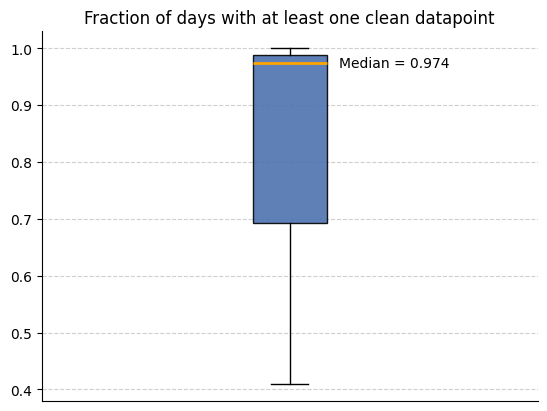

In [ ]:
input_folder = output_folder  # The folder that contains all the site subfolders with the cleaned data and metadata features
csv_name = "active_apple_healthkit_sleep_stage_D_metadata"
files_list = helper_funcs.get_file_paths(
    input_folder, csv_name, Folder_structure=2, site_list=site_list
)

all_participants = []
for path in files_list:
    df = pd.read_csv(path)
    df["total clean datapoints"] = (
        df["total counts"] - df["total timestamps with any error"]
    )
    all_participants.append(
        1
        - (
            len(df[df["total clean datapoints"] == 0])
            / len(df["total clean datapoints"])
        )
    )

helper_funcs.draw_boxplot(df=all_participants, title="Fraction of days with at least one clean datapoint")